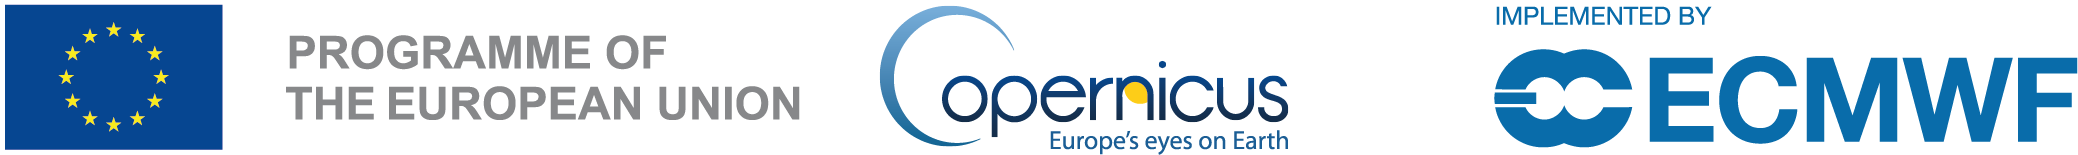

# Tutorial Comparing Near-Surface Wind Speed in CERRA, ERA5 and E-OBS during Storm Ciarán

This tutorial demonstrates how to download, process, and compare near-surface wind speed data from CERRA, ERA5 and E-OBS for [Storm Ciarán](https://en.wikipedia.org/wiki/Storm_Ciar%C3%A1n) in late October–early November 2023. The workflow provides practical, interactive examples for exploring wind conditions during Storm Ciarán. It focuses on daily maximum and daily mean wind speed, spatial comparisons between datasets, assessment of biases relative to observations, and extraction of point-based time series for selected locations. The examples are designed to guide users through common data-processing and analysis steps in Python and can be adapted to explore other locations, periods, or datasets available through the CDS.

### Learning objectives

After completing this notebook, you will:
•	Gain practical experience in downloading near-surface wind speed data from the Copernicus Climate Data Store (CDS); 
•	Learn how to open, inspect, and prepare the datasets for analysis; 
•	Regrid different datasets onto a common spatial grid to enable consistent comparison; 
•	Calculate daily maximum and daily mean wind speed; and 
•	Visualise and compare the resulting datasets using maps and point-based time series.

### Target audience

This notebook is intended for C3S service users, students and early-career researchers seeking to understand and analyse climate data. It is expected that users have a foundational level of Python and experience working in a Jupyter environment to run a Jupyter notebook.

### Workflow overview

The notebook follows these steps:

1. Set up the Python environment and CDS API access.
2. Define file paths and working directories.
3. Download CERRA and ERA5 wind data for Storm Ciarán.
4. Merge data across October and November.
5. Interpolate ERA5 onto the CERRA grid.
6. Calculate daily wind-speed statistics.
7. Plot wind-speed maps for CERRA and ERA5.
8. Download and process E-OBS observations.
9. Compare CERRA and ERA5 against E-OBS.
10. Summary

### Key terminology

- **Near-surface wind speed**: wind speed close to the surface, here represented by 10 m wind speed.
- **Reanalysis**: reconstruction of past atmospheric conditions using observations and weather models.
- **[CERRA](https://cds.climate.copernicus.eu/datasets/reanalysis-cerra-single-levels?tab=documentation)**: Copernicus European Regional ReAnalysis, a high-resolution regional reanalysis for Europe.
- **[ERA5](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=documentation)**: ECMWF global atmospheric reanalysis dataset.
- **[E-OBS](https://cds.climate.copernicus.eu/datasets/insitu-gridded-observations-europe?tab=documentation)**: gridded observational dataset for Europe based on station observations.
- **Regridding**: interpolation of data from one spatial grid to another so that datasets can be compared point by point.
- **Bias**: the difference between a model or reanalysis dataset and a reference dataset, here calculated as reanalysis minus E-OBS.

## 1. Environment setup

Before downloading or processing climate data, we first need to prepare our Python environment. This tutorial uses several Python libraries together with the Copernicus Climate Data Store (CDS) API. The CDS API allows Python to communicate directly with the Copernicus Climate Data Store and download datasets automatically. For plotting nice maps, we use the package cartopy, and for reading the grib-files, we use cfgrib. 

If these packages are already installed on your system, you can skip the installation cell below. Otherwise, uncomment the installation of the relevant packages and run the cell below. 

In [1]:
#!pip install cdsapi 
#!pip install cartopy 
#!pip install -q cfgrib eccodes netcdf4 h5netcdf
#!pip install xarray
#!pip install scipy

#### Enter Your CDS API key
We will request data from the Climate Data Store (CDS) with the help of the CDS API. To do this, you need to pass your personal URL and KEY that together for your CDS API key. To obtain these, register or login to CDS ([cds.climate.copernicus.eu](https://cds.climate.copernicus.eu/)). Under your profile, there is a section on "API key". Copy the string of characters listed after "key" and replace the #### in the code below. Then run the cell. 

In [13]:
import cdsapi
URL = 'https://cds.climate.copernicus.eu/api'
KEY = '####' 
client = cdsapi.Client(url=URL,key=KEY)

You will also need to accept terms of usage in order to download the relevant data from CDS. Stay logged in on CDS. Under "your profile" there is a secton "Licences". Here you need to accept the general terms & conditions (data protection and privacy, and terms of use) as well as these two dataset licences: "CC-BY licence" and "E-OBS product licence. 

Now we will load the python packages used for downloading, analysing and plotting the data. 

In [2]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import subprocess

## 2. Prepare the working directories

Before downloading any data, we need to define where the files will be stored. This tutorial downloads CERRA, ERA5 and E-OBS data for the period 30 October–5 November 2023, covering Storm Ciarán. Since this period spans two calendar months, the CERRA and ERA5 data will be downloaded separately for October and November before being merged later in the notebook. By default, the data are stored in your SCRATCH directory (if available). If no SCRATCH directory exists, the notebook will use your home directory. You may also specify another location if preferred, by . The notebook automatically creates separate folders for each dataset if they do not already exist.

In [3]:
# Find the scratch directory, making a new folder for the data
SCRATCH = os.environ.get("SCRATCH", "/tmp")
WRKDIR = os.path.join(SCRATCH, "Storm_Ciaran") 

# Or comment out the above and define a different path. 
# WRKDIR = ...

print(f"The downloaded data will be stored in directory: \n{WRKDIR}")

The downloaded data will be stored in directory: 
/path/to/directory/


In the working directory, we make folders for CERRA and ERA5 and define the filenames. 

In [4]:
# Making the directories
DATADIR = os.path.join(WRKDIR, "CERRA")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
    
fCERRA1 = os.path.join(DATADIR,"WS_"+"period1"+".grb")
fCERRA2 = os.path.join(DATADIR,"WS_"+"period2"+".grb")


DATADIR = os.path.join(WRKDIR,"ERA5")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
    
fERA1 = os.path.join(DATADIR,"WS_"+"period1"+".nc")
fERA2 = os.path.join(DATADIR,"WS_"+"period2"+".nc")

print(f"The downloaded data will be saved in the files: \n{fCERRA1}\n{fERA1}\n{fCERRA2}\n{fERA2}")

The downloaded data will be saved in the files: 
/path/to/cerra/
/path/to/era5/


## 3. Download the reanalysis datasets
Now we will download the data required for the analysis. We use two reanalysis datasets:

- **CERRA**, a high-resolution regional reanalysis for Europe.
- **ERA5**, a global reanalysis produced by ECMWF.

Both datasets are accessed directly from the Copernicus Climate Data Store ([CDS](https://cds.climate.copernicus.eu/datasets)) using the CDS API. Since Storm Ciarán spans the end of October and the beginning of November 2023, the data must be downloaded separately for each month. The files are around 10-100 MB, and should only take a minute to download. 

In [5]:
year = "2023"
month1, month2 = "10", "11"
days1, days2 = ["30", "31"], ["01", "02", "03", "04", "05"]

### Download CERRA data
The following function submits an api request to the CDS API for CERRA data. The function specifies the dataset to download, the requested variables, the time period, and the output file. Once defined, the function is called twice: once for October and once for November. Once you run the cell, it will take some time for the requests to be processed and the data downloaded. 

In [6]:
def download_cerra(year, month, days, file):
    """ Function writing api request for downloading CERRA data
    """
    dataset = "reanalysis-cerra-single-levels"
    request = {
        "variable": ["10m_wind_speed"],
        "level_type": "surface_or_atmosphere",
        "data_type": ["reanalysis"],
        "product_type": "forecast",
        "year": [year],
        "month": [month],
        "day": days,
        "time": [
            "00:00", "03:00", "06:00", 
            "09:00", "12:00", "15:00",
            "18:00", "21:00",
        ],
        "leadtime_hour": ["1"],
        "data_format": "grib"
    }
    print(request)
    client.retrieve(dataset, request, file)

download_cerra(year, month1, days1, fCERRA1)
download_cerra(year, month2, days2, fCERRA2)

2026-07-20 07:24:57,294 INFO Request ID is 2044bf87-9266-4734-b647-ecf2b56af0e9


{'variable': ['10m_wind_speed'], 'level_type': 'surface_or_atmosphere', 'data_type': ['reanalysis'], 'product_type': 'forecast', 'year': ['2023'], 'month': ['10'], 'day': ['30', '31'], 'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'], 'leadtime_hour': ['1'], 'data_format': 'grib'}


2026-07-20 07:24:57,338 INFO status has been updated to accepted
2026-07-20 07:25:18,668 INFO status has been updated to successful


66b751476a778f5471f3a2fb35e6a646.grib:   0%|          | 0.00/34.9M [00:00<?, ?B/s]

2026-07-20 07:25:19,184 INFO Request ID is a9c096a8-d121-4df2-9cae-599f4599a3da


{'variable': ['10m_wind_speed'], 'level_type': 'surface_or_atmosphere', 'data_type': ['reanalysis'], 'product_type': 'forecast', 'year': ['2023'], 'month': ['11'], 'day': ['01', '02', '03', '04', '05'], 'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'], 'leadtime_hour': ['1'], 'data_format': 'grib'}


2026-07-20 07:25:19,417 INFO status has been updated to accepted
2026-07-20 07:25:42,627 INFO status has been updated to running
2026-07-20 07:25:54,035 INFO status has been updated to successful


658dc5429139f79935005b93aecc33a9.grib:   0%|          | 0.00/87.2M [00:00<?, ?B/s]

### Download ERA5 data

The workflow for ERA5 is identical to CERRA. A separate download function is defined because the CDS dataset name and request parameters differ from those used for CERRA.

In [7]:
def download_era(year, month, days, file):
    """ Function writing api request for downloading ERA5 data
    """
    dataset = "reanalysis-era5-single-levels"
    request = {
        "product_type": "reanalysis",
        "variable": [ "10m_u_component_of_wind","10m_v_component_of_wind"],
        "year": [f"{year}"],
        "month": [f"{month}"],
        "day": days, 
        "time": [
            "00:00", "03:00", "06:00",
            "09:00", "12:00", "15:00",
            "18:00", "21:00"
        ],
        "area": [80, -60, 20, 75],  
        "format": "netcdf"
    }
    client.retrieve(dataset, request, file)

download_era(year, month1, days1, fERA1)
download_era(year, month2, days2, fERA2)

2026-07-20 07:26:08,539 INFO Request ID is 264d3e5a-f535-4b24-a11a-ede2bc764107
2026-07-20 07:26:09,817 INFO status has been updated to accepted
2026-07-20 07:26:23,167 INFO status has been updated to running
2026-07-20 07:26:30,776 INFO status has been updated to successful


1c50ab7a35c7f518570d1ff2bd933a30.nc:   0%|          | 0.00/8.27M [00:00<?, ?B/s]

2026-07-20 07:26:31,295 INFO Request ID is 64412178-036f-442f-9c1b-86fd33d7c7c8
2026-07-20 07:26:31,337 INFO status has been updated to accepted
2026-07-20 07:26:53,192 INFO status has been updated to running
2026-07-20 07:27:21,744 INFO status has been updated to successful


f7338bbb149bf83b8fc93ae17310aeac.nc:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

## 4. Merge monthly files
The CERRA and ERA5 data were downloaded separately for October and November because the storm period crosses a calendar-month boundary. For the analysis, however, it is more convenient to work with one continuous dataset. We therefore merge the October and November files into a single dataset before continuing.

In [7]:
def mergetime(f1, f2, time_dim):
    """ Merges f1 and f2 to a common time-dimension
    """
    ds1 = xr.open_dataset(f1)
    ds2 = xr.open_dataset(f2)
    ds = xr.concat([ds1, ds2], dim=time_dim)
    return ds
    
ds_CERRA = mergetime(fCERRA1, fCERRA2, "time")
ds_ERA = mergetime(fERA1, fERA2, "valid_time")

## 5. Regrid ERA5 to the CERRA grid
CERRA and ERA5 use different spatial grids. Before comparing wind speed from the two datasets, ERA5 must be interpolated onto the same grid as CERRA. This process is called regridding. Here, CERRA is used as the reference grid because it has the higher spatial resolution over Europe.

In [8]:
def remap_to_cerra_grid(era_ds, cerra_ds):
    """ Regrids era_ds on the grid of cerra_ds
    """
    era = era_ds.copy()
    if "valid_time" in era.dims: era = era.rename({"valid_time": "time"})
    era = era.sortby("latitude")
    era = era.sortby("longitude")
    target_longitude = ((cerra_ds["longitude"] + 180) % 360) - 180
    era_on_cerra = era.interp(latitude=cerra_ds["latitude"], longitude=target_longitude, method="linear")
    era_on_cerra = era_on_cerra.assign_coords(latitude=cerra_ds["latitude"], longitude=cerra_ds["longitude"])
    return era_on_cerra

ds_era_on_cerra = remap_to_cerra_grid(ds_ERA, ds_CERRA)

## 6. Calculate daily wind-speed statistics

The downloaded CERRA and ERA5 files contain wind-speed values at sub-daily time steps. We calculate two quantities, daily maximum wind speed, highlighting the strongest winds during each day, and daily mean wind speed, which gives the average wind conditions over each day. Daily maximum wind speed is calculated as the maximum of the eight three-hourly values available for each day. Short-lived wind maxima between these times may therefore not be captured.

In [9]:
# Variable name for 10 m wind speed in CERRA.
var = "si10"

# Calculate daily maximum and daily mean wind speed.
cerra_daily_max = ds_CERRA[var].resample(time="D").max()
cerra_daily_mean = ds_CERRA[var].resample(time="D").mean()

Unlike CERRA, ERA5 stores the horizontal wind as two components: the eastward wind (u10) and the northward wind (v10). We therefore calculate the wind speed as $\sqrt{u^2 + v^2}.$

In [10]:
# Calculate the wind-speed magnitude.
wind_speed = np.sqrt(ds_era_on_cerra["u10"]**2 + ds_era_on_cerra["v10"]**2)
ds_era_on_cerra["wind_speed"] = wind_speed

# Calculate daily maximum and daily mean wind speed.
era_daily_max = ds_era_on_cerra["wind_speed"].resample(time="D").max()
era_daily_mean = ds_era_on_cerra["wind_speed"].resample(time="D").mean()

## 7. Visualise wind-speed fields
The daily maximum and daily mean wind-speed fields can now be visualised and compared between CERRA and ERA5. For a meaningful comparison, both datasets are plotted using the same colour scale and map projection. We find the peak wind day, defined as the day with the highest spatial 99th percentile of daily maximum wind speed, and plot it using the function below. 

In [17]:
# General projection used for the plots in this notebook: 
proj = ccrs.LambertConformal(central_latitude=50.0, central_longitude=8.0, standard_parallels=(50.0,), false_easting=2937000.04508007, false_northing=2937000.00945589, globe=ccrs.Globe(semimajor_axis=6371229.0, semiminor_axis=6371229.0))
wind_map, bias_map = "viridis", "RdBu_r"

def plot_peak_wind_day(cerra_daily, era_daily):
    """ Makes a map of the wind speed of CERRA, ERA5 and the difference between the two
        for the day of maximum wind speed.
    """
    # Find day of maximum wind
    peak_by_day = cerra_daily.quantile(0.99, dim=("y", "x"), skipna=True)
    i = int(peak_by_day.argmax("time"))
    date = pd.to_datetime(cerra_daily.time.isel(time=i).values).strftime("%Y-%m-%d")

    cerra_day = cerra_daily.isel(time=i)
    era_day = era_daily.isel(time=i)
    difference = cerra_day - era_day

    # Set up the figure
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={"projection": proj})
    panels = [(cerra_day, "CERRA", wind_map, 0, 25), (era_day, "ERA5", wind_map, 0, 25), (difference, "CERRA − ERA5", bias_map, -5, 5)]

    # Plotting...
    for ax, (data, title, cmap, vmin, vmax) in zip(axs, panels):
        lon = ((cerra_daily.longitude + 180) % 360) - 180
        lat = cerra_daily.latitude
        mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.coastlines(resolution="50m", linewidth=0.6, zorder=10)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        if title == "CERRA": speed_plot = mesh
        if title == "CERRA − ERA5": difference_plot = mesh

    fig.colorbar(speed_plot, ax=axs[:2], orientation="horizontal", shrink=0.8, pad=0.08, label="Daily maximum 10 m wind speed (m/s)")
    fig.colorbar(difference_plot, ax=axs[2], orientation="horizontal", shrink=0.8, pad=0.08, label="CERRA − ERA5 (m/s)")
    fig.suptitle(f"Storm Ciarán: Maximum Wind Day ({date})", fontsize=15)
    plt.show()

Using the function above, we can plot. 

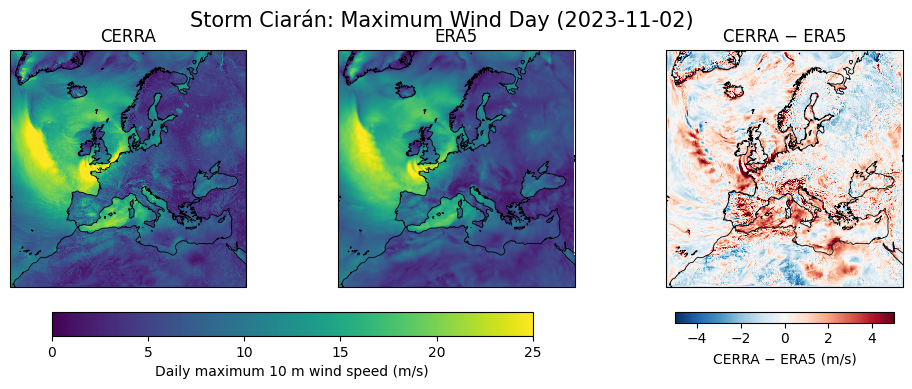

In [95]:
plot_peak_wind_day(cerra_daily_max, era_daily_max)

## 8. Download and prepare E-OBS observations
So far, we have compared two reanalysis datasets: CERRA and ERA5. While this provides insight into their relative differences, it does not tell us which dataset better represents the observed weather conditions. To provide an observational reference, we now introduce E-OBS, an observation-based gridded dataset for Europe, created by interpolating station observations. Unlike CERRA and ERA5, which are produced using numerical weather models combined with observations (reanalyses), E-OBS is generated by interpolating observations from weather stations onto a regular grid. 

In the following sections, we download the E-OBS dataset, extract the Storm Ciarán period, and compare it with CERRA and ERA5.
### Download E-OBS

The E-OBS dataset is downloaded from the Copernicus Climate Data Store using the CDS API. We request daily wind speed on a 0.1° grid, covering the period required for this tutorial. First we again define the directories where we wish to place the observational data, default a folder alongside CERRA and ERA5 called OBSERVATIONS. This file contains data for 2011-2024, and is around 600 MB. 

In [5]:
# Make directories
DATADIR=os.path.join(WRKDIR,"OBSERVATIONS")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)

# Downloaded data is in a zip file.
fEOBS_ZIP = os.path.join(DATADIR, "WS_total.zip")
# Extract as a .nc file.
fEOBS_TOTAL = os.path.join(DATADIR,"WS_"+"total"+".nc")
# We need only the dates of the storm, not the full timeseries. 
fEOBS_SUB = os.path.join(DATADIR, "WS_subsection.nc")
# Lastly, we again will regrid to the CERRA grid
fEOBS_CERRA_GRID = os.path.join(DATADIR, "WS_subsection_on_CERRA.nc")

print(f"Will be saving data in files: \n{fEOBS_ZIP}\n{fEOBS_TOTAL}\n{fEOBS_SUB}\n{fEOBS_CERRA_GRID}")

Will be saving data in files: 
/path/to/observations/


Having defined all filepaths, we setup a similar download function as for the reanalysis data. 

In [11]:
def download_observations(period, file):
    """ Writes api request to download the observation data
    """
    dataset = "insitu-gridded-observations-europe"
    request = {
        "product_type": "ensemble_mean",
        "variable": ["wind_speed"],
        "grid_resolution": "0_1deg",
        "period": period,
        "version": ["31_0e"]
    }
    client.retrieve(dataset, request, file)

In [14]:
download_observations("2011_2024", fEOBS_ZIP)

2026-07-21 06:54:50,991 INFO Request ID is 593a66b3-2fd2-480d-88af-d1f97c531cc0
2026-07-21 06:54:53,627 INFO status has been updated to accepted
2026-07-21 06:55:18,330 INFO status has been updated to running
2026-07-21 06:55:29,761 INFO status has been updated to successful


f7f27d4660385592bfa0c82c6cab9615.zip:   0%|          | 0.00/604M [00:00<?, ?B/s]

### Preparing E-OBS Data
The data is downloaded into a zip file which needs to be extracted. This can be done either using the package zipfile with the cell below, or manually. 

In [11]:
import zipfile

nc_paths = []
# Extract the file from the zip
with zipfile.ZipFile(fEOBS_ZIP, "r") as z:
    for name in z.namelist():
        if name.endswith(".nc"):
            z.extract(name, DATADIR)
            nc_paths.append(os.path.join(DATADIR, name))

os.rename(nc_paths[0], fEOBS_TOTAL)

Now we just want to select the correct dates, and regridd the data to CERRA's resolution. 

In [12]:
# Open the observation data file
ds_OBSERVATIONS = xr.open_dataset(fEOBS_TOTAL)
# Select correct dates
ds_OBSERVATIONS = ds_OBSERVATIONS.sel(time=slice("2023-10-30", "2023-11-05"))
# Regridding to CERRA's resolution
ds_observations_on_cerra = remap_to_cerra_grid(ds_OBSERVATIONS, ds_CERRA)

Once the data is regridded, we can open it. The observations are already daily means of the wind speed, so when comparing the datasets from now on, the daily mean will be used. 

In [13]:
# Open the data - the variable is "fg"
obs_daily_mean = ds_observations_on_cerra["fg"]

## 9. Compare reanalysis datasets with observations
### Spatial maps
To compare the three datasets, we start by looking at the event-mean of the wind speed. E-OBS is used as an observational reference dataset. The comparison is made by considering the difference (bias) between the reanalysis data and observations. Positive values indicate that the reanalysis data has a higher wind speed than the E-OBS. 

In [14]:
def plot_wind_and_bias(cerra_daily_mean, era_daily_mean, obs_daily_mean, day="mean", vmax_speed=10, vmax_bias=4):
    """ Makes plot with five panels of spatial maps for mean wind speed over event, or for a selected day: 
        CERRA, ERA5, E-OBS, CERRA - E-OBS and ERA5 - E-OBS
    """
    # Set up the figure
    fig, axs = plt.subplots(2, 3, figsize=(14, 8), subplot_kw={"projection": proj}, constrained_layout=True)
    
    # Two options: event mean or day mean 
    if day == "mean":
        cer_plot = cerra_daily_mean.mean(dim="time", skipna=True)
        era_plot = era_daily_mean.mean(dim="time", skipna=True)
        obs_plot = obs_daily_mean.mean(dim="time", skipna=True)
        start_date = pd.to_datetime(cerra_daily_mean.time.min().values).strftime("%-d %B")
        end_date = pd.to_datetime(cerra_daily_mean.time.max().values).strftime("%-d %B %Y")
        period_title = f"Event Mean ({start_date}–{end_date})"
        speed_label = "Event-mean 10 m wind speed (m/s)"
    else:
        selected_date = pd.Timestamp(day)
        available_dates = pd.DatetimeIndex(cerra_daily_mean.time.values).normalize()
        if selected_date.normalize() not in available_dates: raise ValueError(f"{selected_date:%Y-%m-%d} is outside the available period {available_dates.min().strftime('%Y-%m-%d')} to {available_dates.max().strftime('%Y-%m-%d')}.")       
        cer_plot = cerra_daily_mean.sel(time=selected_date, method="nearest")
        era_plot = era_daily_mean.sel(time=selected_date, method="nearest")
        obs_plot = obs_daily_mean.sel(time=selected_date, method="nearest")
        period_title = f"{selected_date.day} {selected_date:%B %Y}"
        speed_label = "10m Wind Speed (m/s)"

    # Plot only where also observation data exists
    cer_plot = cer_plot.where(np.isfinite(obs_plot))
    era_plot = era_plot.where(np.isfinite(obs_plot))
    bias_cer = (cer_plot - obs_plot).where(np.isfinite(obs_plot))
    bias_era = (era_plot - obs_plot).where(np.isfinite(obs_plot))

    axs[0, 0].set_title("E-OBS", fontsize=13, pad=10)
    axs[0, 1].set_title("CERRA", fontsize=13, pad=10)
    axs[0, 2].set_title("ERA5", fontsize=13, pad=10)
    axs[1, 0].axis("off")
    axs[1, 1].set_title("CERRA − E-OBS", fontsize=13, pad=10)
    axs[1, 2].set_title("ERA5 − E-OBS", fontsize=13, pad=10)

    panels = {(0, 0): (obs_plot, 0, vmax_speed, wind_map), (0, 1): (cer_plot, 0, vmax_speed, wind_map), (0, 2): (era_plot, 0, vmax_speed, wind_map), (1, 1): (bias_cer, -vmax_bias, vmax_bias, bias_map), (1, 2): (bias_era, -vmax_bias, vmax_bias, bias_map)}
    m_speed, m_bias = None, None

    for (row, col), (data, vmin, vmax, cmap) in panels.items():
        ax = axs[row, col]
        pm = ax.pcolormesh(((cerra_daily_mean["longitude"] + 180) % 360) - 180, cerra_daily_mean["latitude"], data, transform=ccrs.PlateCarree(), shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.coastlines(resolution="50m", linewidth=0.6)
        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0 and m_speed is None: m_speed = pm
        if row == 1 and m_bias is None: m_bias = pm

    cbar1 = fig.colorbar(m_speed, ax=axs[0, :], orientation="vertical", shrink=0.95, pad=0.03, label=speed_label)
    cbar2 = fig.colorbar(m_bias, ax=axs[1, 1:], orientation="vertical", shrink=0.95, pad=0.03, label="Reanalysis − E-OBS Bias (m/s)")
    fig.suptitle(f"Storm Ciarán: 10 m Wind Speed and Bias — {period_title}", fontsize=15)
    
    plt.show()

Now we can plot. Feel free to change the day for another day in the relevant period, or use "mean" to see the event mean. 

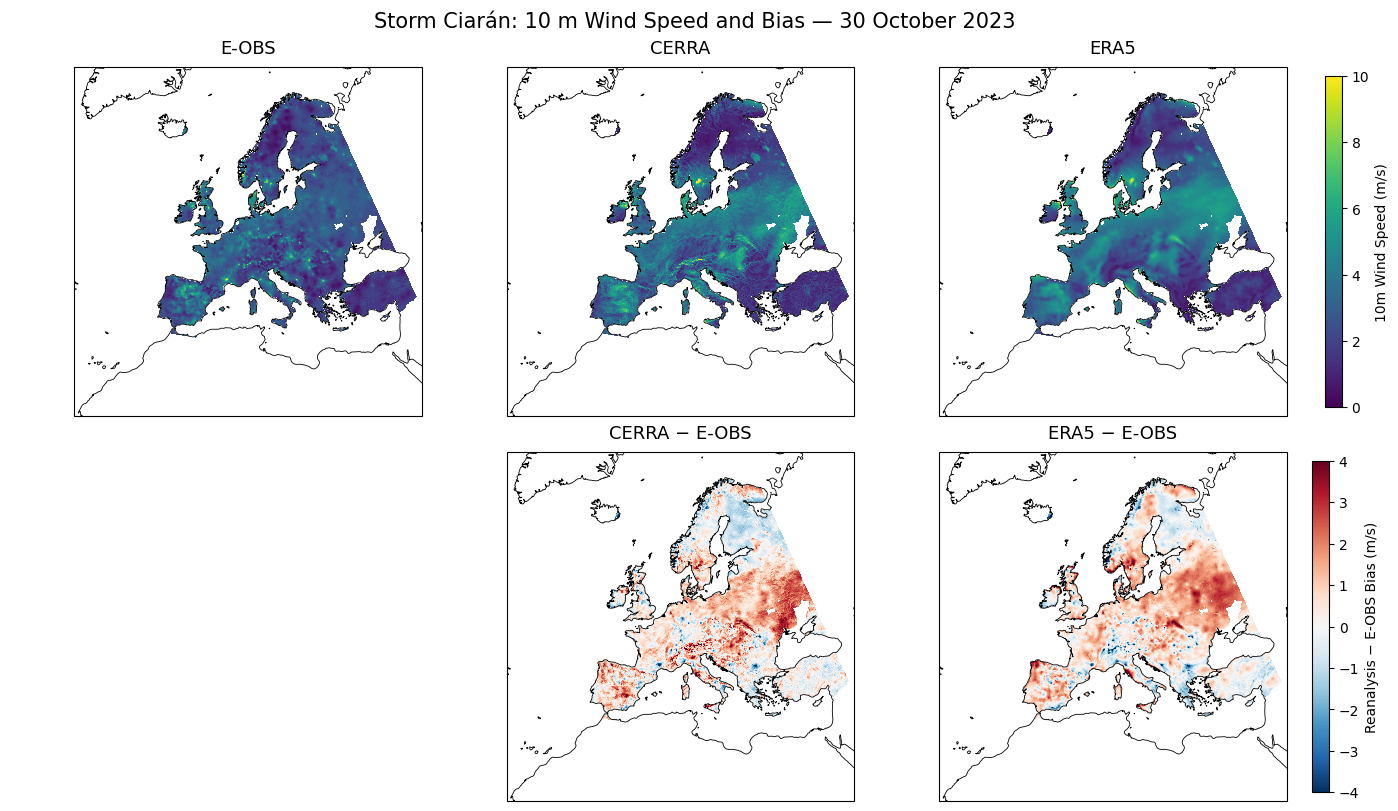

In [114]:
#day = "mean"
day = "2023-10-30"

plot_wind_and_bias(cerra_daily_mean, era_daily_mean, obs_daily_mean, day=day)

## Timeseries 
Lastly we look at a timeseries for the wind speed of the grid cell closest to a given coordinate. To do this, we first define a function which finds and selects the closest grid-point, and then plots a time series for the three datasets, as well as the difference between the gridded observations and the reanalysis. 

In [30]:
def point_timeseries_with_locator(lat0, lon0, cer, era, obs, time_step=0, pad=120):
    """ Makes time series of the wind speed at a given longitude and latitude for CERRA, ERA5, E-OBS 
        and the differences, as well as a little map indicating the location of the selected point.
    """
    # Set up the figure: 1 time series, one bias series and one map
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.2, 1.3], height_ratios=[2.2, 1], hspace=0.2, wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    axb = fig.add_subplot(gs[1, 0], sharex=ax)
    axm =  fig.add_subplot(gs[:, 1], projection=proj)
    
    # Find the nearest grid point to lat0, lon0
    cer_lon_plot = ((cer["longitude"] + 180) % 360) - 180
    dist2 = ((cer_lon_plot - lon0) * np.cos(np.deg2rad(lat0))) ** 2 + (cer["latitude"] - lat0) ** 2
    min_index = np.unravel_index(np.nanargmin(dist2.values), dist2.shape)
    dim_to_index = dict(zip(dist2.dims, min_index))
    j = dim_to_index["y"]
    i = dim_to_index["x"]
    selected_lon = float(cer_lon_plot.isel(y=j, x=i))
    selected_lat = float(cer["latitude"].isel(y=j, x=i))

    print(f"Selected grid cell: y={j}, x={i}")
    print(f"Target lon/lat: {lon0:.3f}, {lat0:.3f}")
    print(f"Nearest grid-cell lon/lat: {selected_lon:.3f}, {selected_lat:.3f}")

    cer_ts = cer.isel(y=j, x=i)["si10"]
    era_ts = era.isel(y=j, x=i)["wind_speed"]
    obs_ts = obs.isel(y=j, x=i)

    # Plot the time series: both 3-hour data and daily means 
    cer_daily = cer_ts.resample(time="D").mean()
    era_daily = era_ts.resample(time="D").mean()
    ax.plot(cer_ts.time, cer_ts, label="CERRA 3-hourly", linewidth=1, color="tab:blue", linestyle="--")
    ax.plot(cer_daily.time, cer_daily, label="CERRA daily mean", linewidth=2, color="tab:blue", marker="o")
    ax.plot(era_ts.time, era_ts, label="ERA5 3-hourly", linewidth=1, color="tab:orange", linestyle="--")
    ax.plot(era_daily.time, era_daily, label="ERA5 daily mean", linewidth=2, color="tab:orange", marker="o")
    ax.plot(obs_ts.time, obs_ts, label="E-OBS daily mean", linewidth=2, color="tab:green", marker="o")
    ax.set_title(f"Wind Speed at Selected Point \nTarget: {lat0:.2f}°N, {lon0:.2f}°E")
    ax.set_ylabel("Wind speed (m/s)")
    ax.legend(frameon=True, loc="upper left", facecolor="white", framealpha=0.75, edgecolor="k")
    ax.tick_params(axis="x", labelbottom=False)

    # plot the timeseries of reanalysis - observations
    obs_at_hourly_times = obs_ts.reindex(time=cer_ts.time, method="ffill")
    cer_hourly_bias = cer_ts - obs_at_hourly_times
    era_hourly_bias = era_ts - obs_at_hourly_times
    axb.plot(cer_hourly_bias.time, cer_hourly_bias, color="tab:blue", linewidth=1.3, label="CERRA − E-OBS daily")
    axb.plot(era_hourly_bias.time, era_hourly_bias, color="tab:orange", linewidth=1.3, label="ERA5 − E-OBS daily mean")
    axb.axhline(0, color="black", linewidth=0.8, linestyle="--")
    axb.set_title("Difference from E-OBS", fontsize=11)
    axb.set_ylabel("Bias (m/s)")
    axb.set_xlabel("Date")
    axb.legend(frameon=True, ncol=2, fontsize=9, facecolor="white", framealpha=0.75, edgecolor="k")

    # plot location of the selected grid-cell
    date = pd.Timestamp(cer.time.isel(time=time_step).values)
    bg = cer["si10"].isel(time=time_step, drop=True).squeeze().where(np.isfinite(obs.sel(time=date, method="nearest").squeeze()))
    region = {"y": slice(max(j-pad, 0), min(j+pad+1, bg.sizes["y"])), "x": slice(max(i-pad, 0), min(i+pad+1, bg.sizes["x"]))}
    bg_zoom, lon_zoom, lat_zoom = bg.isel(region), cer_lon_plot.isel(region), cer["latitude"].isel(region)
    mesh = axm.pcolormesh(lon_zoom, lat_zoom, bg_zoom, transform=ccrs.PlateCarree(), shading="auto", cmap=wind_map)
    axm.scatter(selected_lon, selected_lat, transform=ccrs.PlateCarree(), marker="s", s=180, facecolors="none", edgecolors="cyan", linewidths=3, zorder=20)
    xy = proj.transform_points(ccrs.PlateCarree(), lon_zoom.values, lat_zoom.values)
    axm.set_xlim(np.nanmin(xy[..., 0]), np.nanmax(xy[..., 0]))
    axm.set_ylim(np.nanmin(xy[..., 1]), np.nanmax(xy[..., 1]))
    axm.set_box_aspect(1)
    axm.coastlines(resolution="50m", linewidth=0.8)
    axm.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    axm.set_title(f"Selected grid cell\n{selected_lat:.2f}°N, {selected_lon:.2f}°E")
    
    cbar = fig.colorbar(mesh, ax=axm, orientation="vertical", shrink=0.8, pad=0.02)
    cbar.set_label(f"CERRA wind speed on {date:%Y-%m-%d} (m/s)")

    
    plt.show()

Now we can produce the last plot. Feel free to choose a coordinate of your liking. Note that the coordinate has to be on land for E-OBS to have datapoints. 

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Selected grid cell: y=737, x=524
Target lon/lat: 7.000, 60.000
Nearest grid-cell lon/lat: 7.027, 59.983


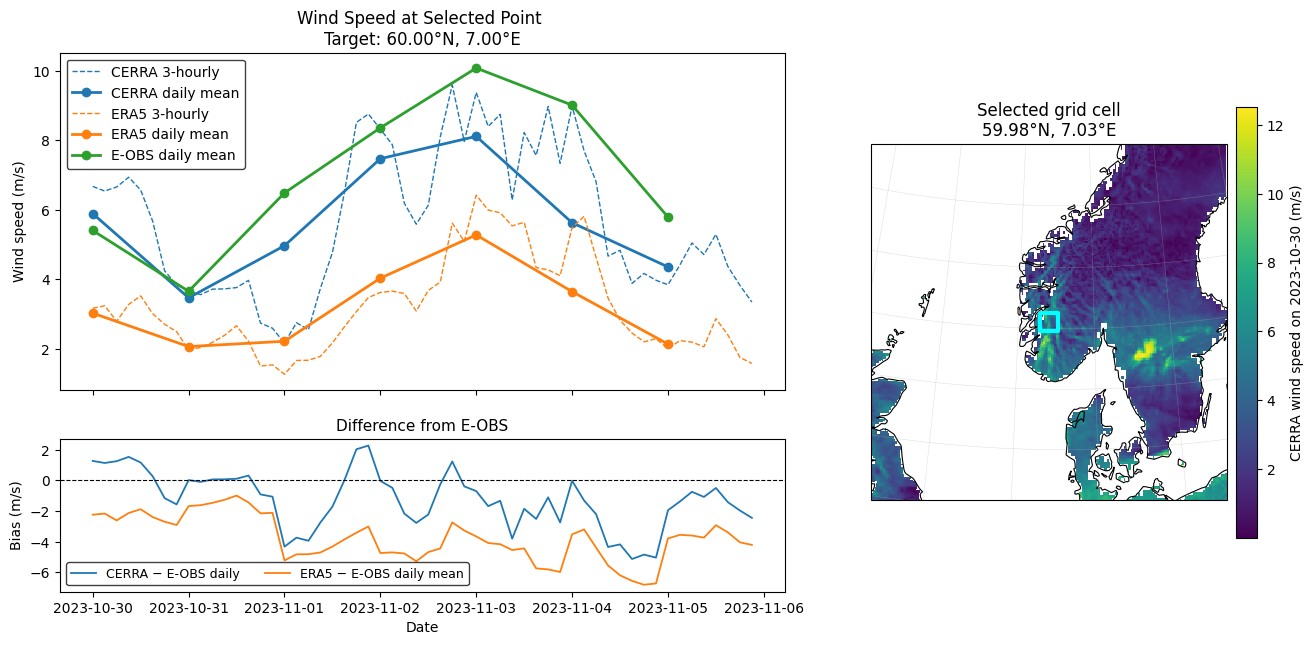

In [31]:
lat0 = 60
lon0 = 7

point_timeseries_with_locator(lat0, lon0, ds_CERRA, ds_era_on_cerra, obs_daily_mean)

## 10. Summary

In this tutorial, we downloaded near-surface wind data from CERRA and
ERA5 and compared the datasets during Storm Ciarán. We then included
E-OBS as an observation-based gridded reference. The notebook demonstrated how to regrid datasets, calculate daily
statistics, create spatial difference maps, and inspect a selected
location using time series.